# การเปรียบเทียบ Decision Tree และ SVM สำหรับทำนายการเสียชีวิตของผู้ป่วย COVID-19

Notebook นี้สรุปและเปรียบเทียบผลลัพธ์ของโมเดล **Decision Tree** และ **Support Vector Machine (SVM)** โดยใช้ผลจาก **test set ชุดเดียวกัน**

> จุดประสงค์คือการศึกษาและเปรียบเทียบโมเดลเท่านั้น ไม่ใช่เครื่องมือวินิจฉัยหรือใช้ตัดสินใจทางการแพทย์

ตัวแปรเป้าหมายคือ `DEATH_STATUS`

- `0` = รอดชีวิต (Survived)
- `1` = เสียชีวิต (Died)

เกณฑ์หลักในการเลือกโมเดลคือ **F1-score ของคลาส Died** และพิจารณา Recall กับ PR-AUC ประกอบ เพราะข้อมูลคลาส Died มีเพียง 7.34% ของข้อมูลทั้งหมด

## 1. หลักการป้องกัน Data Leakage

Notebook นี้ **ไม่มีการเทรนหรือปรับพารามิเตอร์ใหม่** แต่จะอ่านผลลัพธ์ที่บันทึกจาก Notebook ของแต่ละโมเดล เพื่อไม่ให้นำผลจาก test set กลับไปมีอิทธิพลต่อการปรับโมเดล

- Decision Tree ปรับพารามิเตอร์ด้วย Stratified 5-Fold Cross-Validation บน training set เท่านั้น
- SVM ปรับพารามิเตอร์ด้วย Stratified 3-Fold Cross-Validation บนข้อมูลตัวอย่างที่มาจาก training set เท่านั้น แล้วเทรนโมเดลสุดท้ายด้วย training set ทั้งหมด
- test set ถูกใช้ครั้งเดียวเพื่อประเมินโมเดลที่ปรับพารามิเตอร์เสร็จแล้ว
- หลังเห็นผล test set จะไม่นำผลนั้นกลับไปปรับพารามิเตอร์อีก

ดังนั้นคะแนนใน Notebook นี้เป็น **ผลประเมินสุดท้าย** ไม่ใช่คะแนนสำหรับเลือก hyperparameters

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown

# รองรับการเปิด Notebook จากโฟลเดอร์โปรเจกต์หรือจากโฟลเดอร์ notebooks
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures" / "model_comparison"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DT_METRICS_PATH = RESULTS_DIR / "decision_tree_metrics.json"
SVM_METRICS_PATH = RESULTS_DIR / "svm_metrics.json"
SUMMARY_PATH = RESULTS_DIR / "model_comparison_summary.json"

sns.set_theme(style="whitegrid")

# เลือกฟอนต์ภาษาไทยที่มีในเครื่องโดยอัตโนมัติ
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
thai_font_candidates = ["Leelawadee UI", "Tahoma", "Nirmala UI", "Arial Unicode MS", "DejaVu Sans"]
thai_font = next((font for font in thai_font_candidates if font in available_fonts), "DejaVu Sans")
plt.rcParams["font.family"] = thai_font
plt.rcParams["axes.unicode_minus"] = False

MODEL_COLORS = {"Decision Tree": "#2F80ED", "SVM": "#F2994A"}

def save_figure(filename):
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=160, bbox_inches="tight", facecolor="white")
    print(f"บันทึกกราฟ: {path.relative_to(PROJECT_ROOT)}")

print(f"โฟลเดอร์โปรเจกต์: {PROJECT_ROOT}")
print(f"ฟอนต์ที่ใช้ในกราฟ: {thai_font}")

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\ntwx7\\AppData\\Local\\matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


โฟลเดอร์โปรเจกต์: C:\labjajaja\kaggle-model
ฟอนต์ที่ใช้ในกราฟ: Leelawadee UI


## 2. โหลดผลลัพธ์ของทั้งสองโมเดล

ผลลัพธ์มาจากไฟล์ JSON ที่ Notebook ของแต่ละโมเดลบันทึกหลังประเมิน test set แล้ว การอ่านไฟล์เหล่านี้ไม่ทำให้เกิด data leakage เพราะไม่มีการฝึกโมเดลเพิ่มเติม

In [2]:
for path in [DT_METRICS_PATH, SVM_METRICS_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"ไม่พบไฟล์ผลลัพธ์: {path}")

with DT_METRICS_PATH.open(encoding="utf-8") as file:
    decision_tree = json.load(file)

with SVM_METRICS_PATH.open(encoding="utf-8") as file:
    svm = json.load(file)

models = {"Decision Tree": decision_tree, "SVM": svm}
required_keys = {
    "accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc",
    "confusion_matrix", "train_rows", "test_rows", "input_feature_count",
    "encoded_feature_count", "best_params", "dummy_baseline"
}

for model_name, result in models.items():
    missing_keys = required_keys - result.keys()
    if missing_keys:
        raise KeyError(f"{model_name} ขาดข้อมูล: {sorted(missing_keys)}")

print("โหลดผลลัพธ์ของ Decision Tree และ SVM สำเร็จ")

โหลดผลลัพธ์ของ Decision Tree และ SVM สำเร็จ


## 3. ตรวจสอบความยุติธรรมของการเปรียบเทียบ

ก่อนเปรียบเทียบคะแนน ต้องตรวจว่าทั้งสองโมเดลใช้จำนวนข้อมูลและจำนวน features เท่ากัน หากค่าใดไม่ตรงกัน Notebook จะหยุดเพื่อป้องกันการสรุปผลที่ไม่ยุติธรรม

In [3]:
fairness_fields = {
    "จำนวนแถว Training set": "train_rows",
    "จำนวนแถว Test set": "test_rows",
    "จำนวน Features ก่อนเข้ารหัส": "input_feature_count",
    "จำนวน Features หลังเข้ารหัส": "encoded_feature_count",
    "จำนวนแถวซ้ำที่ตรวจพบ": "duplicate_rows_audit",
}

fairness_rows = []
for thai_label, key in fairness_fields.items():
    dt_value = decision_tree[key]
    svm_value = svm[key]
    fairness_rows.append({
        "รายการตรวจสอบ": thai_label,
        "Decision Tree": dt_value,
        "SVM": svm_value,
        "ผลการตรวจสอบ": "ตรงกัน" if dt_value == svm_value else "ไม่ตรงกัน",
    })

fairness_table = pd.DataFrame(fairness_rows)
display(fairness_table)

assert all(fairness_table["ผลการตรวจสอบ"] == "ตรงกัน"), (
    "ข้อมูลของสองโมเดลไม่ตรงกัน กรุณาตรวจ train/test split และ preprocessing ก่อนเปรียบเทียบ"
)

assert decision_tree["dummy_baseline"] == svm["dummy_baseline"], (
    "ค่า baseline ไม่ตรงกัน อาจหมายถึงใช้ test set คนละชุด"
)

print("ผ่านการตรวจสอบ: ทั้งสองโมเดลใช้ขนาดข้อมูล, features และ baseline ตรงกัน")
print("เงื่อนไขจาก README: test_size=0.20, random_state=42 และ stratify=y")

,รายการตรวจสอบ,Decision Tree,SVM,ผลการตรวจสอบ
0,จำนวนแถว Training set,20000,20000,ตรงกัน
1,จำนวนแถว Test set,5000,5000,ตรงกัน
2,จำนวน Features ก่อนเข้ารหัส,18,18,ตรงกัน
3,จำนวน Features หลังเข้ารหัส,51,51,ตรงกัน
4,จำนวนแถวซ้ำที่ตรวจพบ,11992,11992,ตรงกัน


ผ่านการตรวจสอบ: ทั้งสองโมเดลใช้ขนาดข้อมูล, features และ baseline ตรงกัน
เงื่อนไขจาก README: test_size=0.20, random_state=42 และ stratify=y


### ความหมายของ Metrics

- **Accuracy**: สัดส่วนที่ทำนายถูกทั้งหมด แต่สามารถดูดีเกินจริงเมื่อข้อมูลไม่สมดุล
- **Precision (Died)**: ในกลุ่มที่โมเดลทำนายว่าเสียชีวิต มีผู้เสียชีวิตจริงกี่ส่วน
- **Recall (Died)**: ในกลุ่มผู้เสียชีวิตจริง โมเดลตรวจพบได้กี่ส่วน
- **F1-score (Died)**: ค่าที่สมดุลระหว่าง Precision และ Recall และเป็นเกณฑ์หลักของโครงงาน
- **ROC-AUC**: ความสามารถในการจัดอันดับระหว่างสองคลาสในภาพรวม
- **PR-AUC**: ความสามารถด้าน Precision-Recall ซึ่งสำคัญมากเมื่อคลาส Died มีจำนวนน้อย

ทุก metric ในตารางถัดไปมาจาก **test set ชุดเดียวกัน** และค่ายิ่งสูงยิ่งดี

In [4]:
metric_info = [
    ("Accuracy", "accuracy"),
    ("Precision (Died)", "precision"),
    ("Recall (Died)", "recall"),
    ("F1-score (Died)", "f1_score"),
    ("ROC-AUC", "roc_auc"),
    ("PR-AUC", "pr_auc"),
]

comparison_rows = []
for thai_label, key in metric_info:
    dt_value = decision_tree[key]
    svm_value = svm[key]
    comparison_rows.append({
        "ตัวชี้วัด": thai_label,
        "Decision Tree": dt_value,
        "SVM": svm_value,
        "ผลต่าง SVM - Tree": svm_value - dt_value,
        "โมเดลที่ดีกว่า": "SVM" if svm_value > dt_value else "Decision Tree" if dt_value > svm_value else "เท่ากัน",
    })

comparison_table = pd.DataFrame(comparison_rows)
display(
    comparison_table.style
    .format({
        "Decision Tree": "{:.2%}",
        "SVM": "{:.2%}",
        "ผลต่าง SVM - Tree": "{:+.2%}",
    })
    .background_gradient(subset=["Decision Tree", "SVM"], cmap="YlGn")
)

,ตัวชี้วัด,Decision Tree,SVM,ผลต่าง SVM - Tree,โมเดลที่ดีกว่า
0,Accuracy,87.28%,87.16%,-0.12%,Decision Tree
1,Precision (Died),35.04%,36.01%,+0.97%,SVM
2,Recall (Died),85.83%,96.46%,+10.63%,SVM
3,F1-score (Died),49.76%,52.44%,+2.68%,SVM
4,ROC-AUC,88.80%,94.32%,+5.52%,SVM
5,PR-AUC,48.50%,45.76%,-2.75%,Decision Tree


## 4. ภาพรวมคะแนนบน Test Set

กราฟนี้ช่วยดูภาพรวมของทั้ง 6 metrics แต่ไม่ควรเลือกโมเดลจาก Accuracy เพียงอย่างเดียว เพราะโมเดลที่ทำนายว่า “รอดชีวิต” ทุกคนก็ได้ Accuracy ถึง 92.66% ทั้งที่ตรวจผู้เสียชีวิตไม่ได้เลย

บันทึกกราฟ: results\figures\model_comparison\01_all_metrics_comparison.png


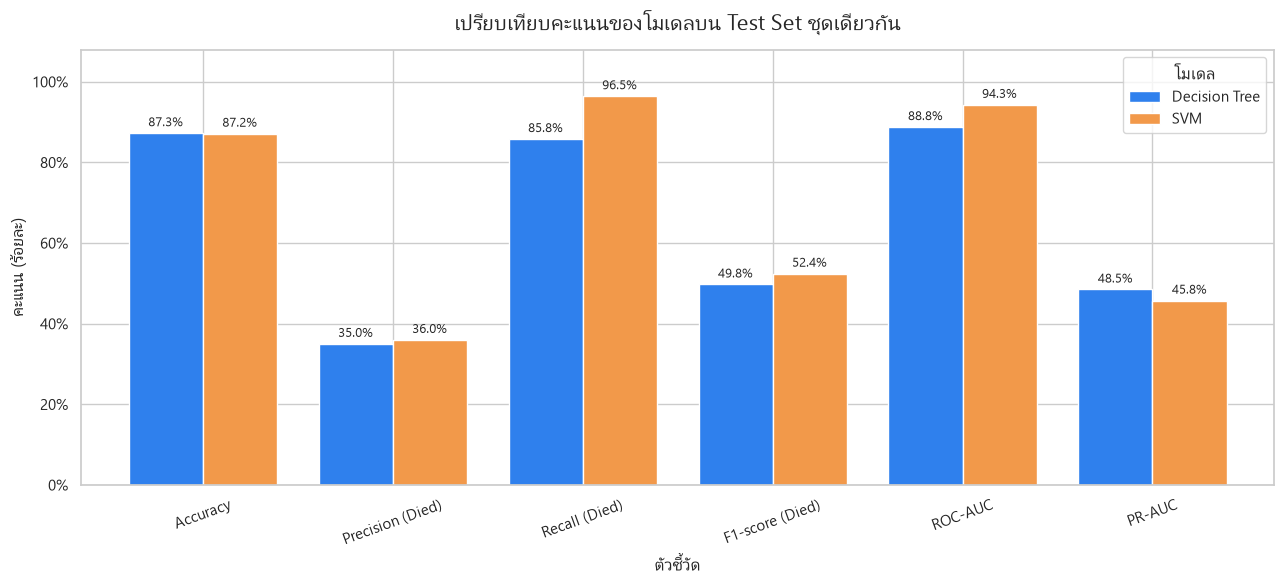

คำแปลผล: SVM เด่นกว่าใน Recall, F1-score และ ROC-AUC ส่วน Decision Tree เด่นกว่าเล็กน้อยใน Accuracy และ PR-AUC


In [5]:
plot_table = comparison_table.set_index("ตัวชี้วัด")[["Decision Tree", "SVM"]]
ax = plot_table.plot(
    kind="bar",
    figsize=(13, 6),
    color=[MODEL_COLORS["Decision Tree"], MODEL_COLORS["SVM"]],
    width=0.78,
)
ax.set_title("เปรียบเทียบคะแนนของโมเดลบน Test Set ชุดเดียวกัน", fontsize=16, pad=14)
ax.set_xlabel("ตัวชี้วัด")
ax.set_ylabel("คะแนน (ร้อยละ)")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1.08)
ax.tick_params(axis="x", rotation=20)
ax.legend(title="โมเดล")

for container in ax.containers:
    ax.bar_label(container, labels=[f"{value:.1%}" for value in container.datavalues], padding=3, fontsize=9)

plt.tight_layout()
save_figure("01_all_metrics_comparison.png")
plt.show()

print("คำแปลผล: SVM เด่นกว่าใน Recall, F1-score และ ROC-AUC ส่วน Decision Tree เด่นกว่าเล็กน้อยใน Accuracy และ PR-AUC")

## 5. เปรียบเทียบการตรวจจับคลาส Died

สามค่านี้สะท้อนการทำนายผู้เสียชีวิตโดยตรง:

- Recall สูง หมายถึงพลาดผู้เสียชีวิตจริงน้อย
- Precision สูง หมายถึงการแจ้งว่าเสี่ยงเสียชีวิตมีความถูกต้องมากขึ้น
- F1-score สูง หมายถึงสมดุลของ Precision และ Recall ดีขึ้น

บันทึกกราฟ: results\figures\model_comparison\02_died_class_metrics.png


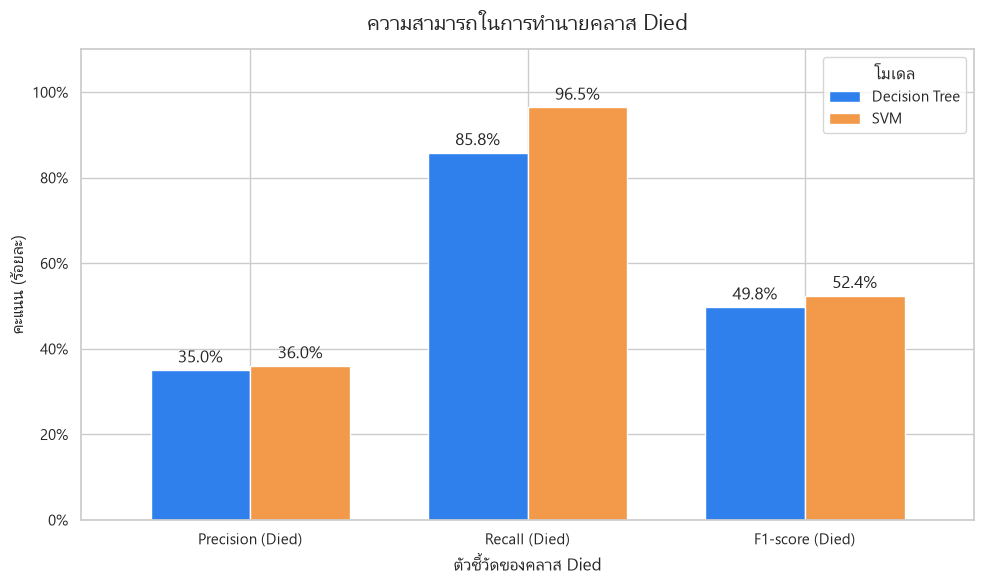

SVM มี Recall สูงกว่า Decision Tree 10.63% จุด
SVM มี F1-score สูงกว่า Decision Tree 2.68% จุด


In [6]:
positive_metrics = comparison_table[
    comparison_table["ตัวชี้วัด"].isin(["Precision (Died)", "Recall (Died)", "F1-score (Died)"])
].set_index("ตัวชี้วัด")[["Decision Tree", "SVM"]]

ax = positive_metrics.plot(
    kind="bar",
    figsize=(10, 6),
    color=[MODEL_COLORS["Decision Tree"], MODEL_COLORS["SVM"]],
    width=0.72,
)
ax.set_title("ความสามารถในการทำนายคลาส Died", fontsize=16, pad=14)
ax.set_xlabel("ตัวชี้วัดของคลาส Died")
ax.set_ylabel("คะแนน (ร้อยละ)")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1.10)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="โมเดล")

for container in ax.containers:
    ax.bar_label(container, labels=[f"{value:.1%}" for value in container.datavalues], padding=3)

plt.tight_layout()
save_figure("02_died_class_metrics.png")
plt.show()

recall_gain = svm["recall"] - decision_tree["recall"]
f1_gain = svm["f1_score"] - decision_tree["f1_score"]
print(f"SVM มี Recall สูงกว่า Decision Tree {recall_gain:.2%} จุด")
print(f"SVM มี F1-score สูงกว่า Decision Tree {f1_gain:.2%} จุด")

## 6. ROC-AUC และ PR-AUC

- ROC-AUC สรุปความสามารถในการแยกสองคลาสในภาพรวม
- PR-AUC เน้นคลาส Died ซึ่งเป็นคลาสส่วนน้อย จึงควรให้น้ำหนักในการตีความมากเป็นพิเศษ

กราฟนี้แสดงค่า AUC ที่บันทึกจากผลทำนายบน test set ส่วนเส้นโค้ง ROC และ Precision-Recall แบบเต็มอยู่ใน Notebook ของแต่ละโมเดล

บันทึกกราฟ: results\figures\model_comparison\03_auc_comparison.png


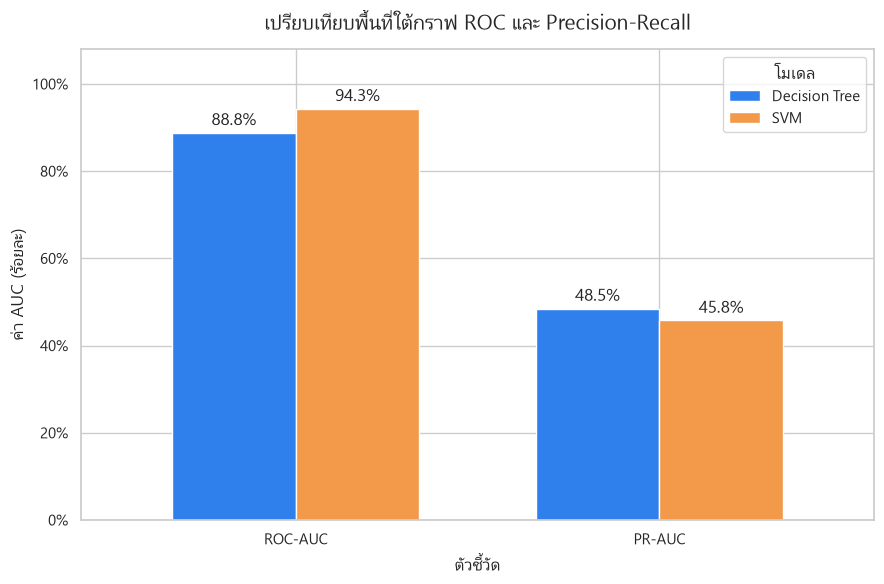

SVM มี ROC-AUC สูงกว่า 5.52% จุด
Decision Tree มี PR-AUC สูงกว่า 2.75% จุด


In [7]:
auc_table = comparison_table[
    comparison_table["ตัวชี้วัด"].isin(["ROC-AUC", "PR-AUC"])
].set_index("ตัวชี้วัด")[["Decision Tree", "SVM"]]

ax = auc_table.plot(
    kind="bar",
    figsize=(9, 6),
    color=[MODEL_COLORS["Decision Tree"], MODEL_COLORS["SVM"]],
    width=0.68,
)
ax.set_title("เปรียบเทียบพื้นที่ใต้กราฟ ROC และ Precision-Recall", fontsize=15, pad=14)
ax.set_xlabel("ตัวชี้วัด")
ax.set_ylabel("ค่า AUC (ร้อยละ)")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1.08)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="โมเดล")

for container in ax.containers:
    ax.bar_label(container, labels=[f"{value:.1%}" for value in container.datavalues], padding=3)

plt.tight_layout()
save_figure("03_auc_comparison.png")
plt.show()

print(f"SVM มี ROC-AUC สูงกว่า {svm['roc_auc'] - decision_tree['roc_auc']:.2%} จุด")
print(f"Decision Tree มี PR-AUC สูงกว่า {decision_tree['pr_auc'] - svm['pr_auc']:.2%} จุด")

## 7. Confusion Matrix

แถวคือค่าจริงและคอลัมน์คือค่าที่โมเดลทำนาย:

- **True Negative (TN)**: รอดชีวิตจริง และทำนายว่ารอดชีวิต
- **False Positive (FP)**: รอดชีวิตจริง แต่ทำนายว่าเสียชีวิต
- **False Negative (FN)**: เสียชีวิตจริง แต่ทำนายว่ารอดชีวิต — เป็นข้อผิดพลาดที่สำคัญมากในบริบทนี้
- **True Positive (TP)**: เสียชีวิตจริง และทำนายว่าเสียชีวิต

บันทึกกราฟ: results\figures\model_comparison\04_confusion_matrices.png


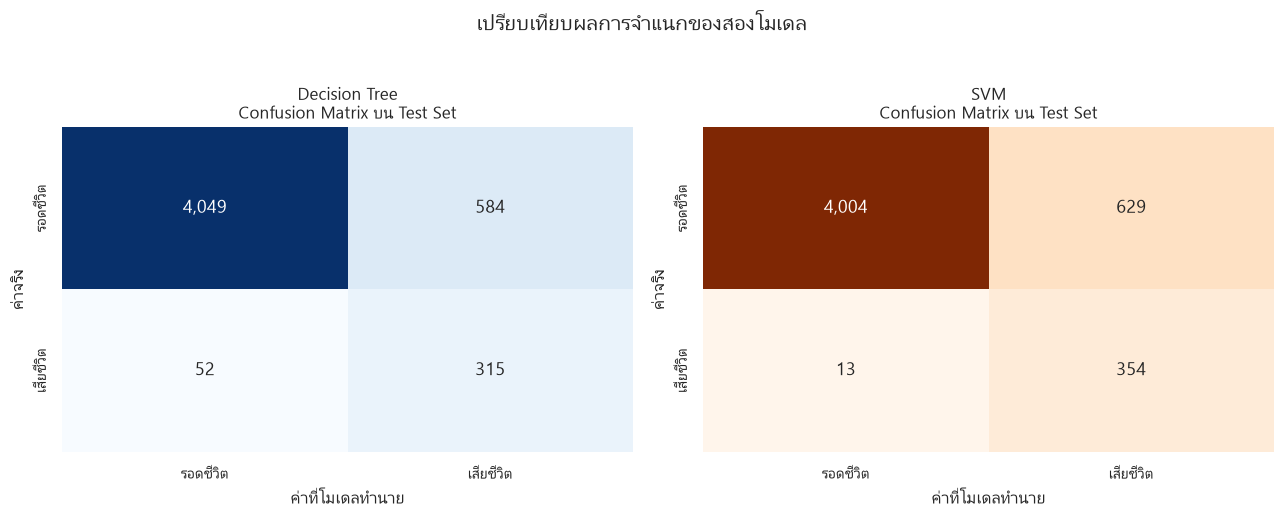

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (model_name, result) in zip(axes, models.items()):
    matrix = np.array(result["confusion_matrix"])
    sns.heatmap(
        matrix,
        annot=True,
        fmt=",d",
        cmap="Blues" if model_name == "Decision Tree" else "Oranges",
        cbar=False,
        xticklabels=["รอดชีวิต", "เสียชีวิต"],
        yticklabels=["รอดชีวิต", "เสียชีวิต"],
        ax=ax,
        annot_kws={"fontsize": 13},
    )
    ax.set_title(f"{model_name}\nConfusion Matrix บน Test Set")
    ax.set_xlabel("ค่าที่โมเดลทำนาย")
    ax.set_ylabel("ค่าจริง")

plt.suptitle("เปรียบเทียบผลการจำแนกของสองโมเดล", fontsize=16, y=1.03)
plt.tight_layout()
save_figure("04_confusion_matrices.png")
plt.show()

,ทายถูกว่ารอดชีวิต (TN),แจ้งเสียชีวิตเกินจริง (FP),พลาดผู้เสียชีวิต (FN),ตรวจพบผู้เสียชีวิต (TP)
โมเดล,,,,
Decision Tree,4049,584,52,315
SVM,4004,629,13,354


บันทึกกราฟ: results\figures\model_comparison\05_error_comparison.png


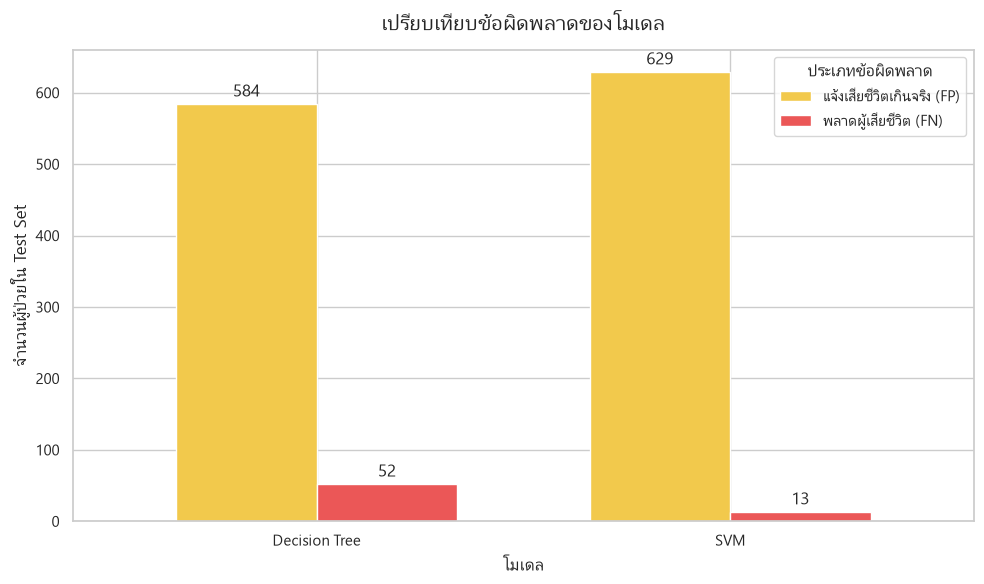

SVM พลาดผู้เสียชีวิตน้อยกว่า Decision Tree 39 คน
แต่ SVM แจ้งเสียชีวิตเกินจริงมากกว่า Decision Tree 45 คน


In [9]:
error_rows = []
for model_name, result in models.items():
    tn, fp, fn, tp = np.array(result["confusion_matrix"]).ravel()
    error_rows.append({
        "โมเดล": model_name,
        "ทายถูกว่ารอดชีวิต (TN)": int(tn),
        "แจ้งเสียชีวิตเกินจริง (FP)": int(fp),
        "พลาดผู้เสียชีวิต (FN)": int(fn),
        "ตรวจพบผู้เสียชีวิต (TP)": int(tp),
    })

error_table = pd.DataFrame(error_rows).set_index("โมเดล")
display(error_table)

ax = error_table[["แจ้งเสียชีวิตเกินจริง (FP)", "พลาดผู้เสียชีวิต (FN)"]].plot(
    kind="bar",
    figsize=(10, 6),
    color=["#F2C94C", "#EB5757"],
    width=0.68,
)
ax.set_title("เปรียบเทียบข้อผิดพลาดของโมเดล", fontsize=16, pad=14)
ax.set_xlabel("โมเดล")
ax.set_ylabel("จำนวนผู้ป่วยใน Test Set")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="ประเภทข้อผิดพลาด")
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
save_figure("05_error_comparison.png")
plt.show()

dt_fn = error_table.loc["Decision Tree", "พลาดผู้เสียชีวิต (FN)"]
svm_fn = error_table.loc["SVM", "พลาดผู้เสียชีวิต (FN)"]
dt_fp = error_table.loc["Decision Tree", "แจ้งเสียชีวิตเกินจริง (FP)"]
svm_fp = error_table.loc["SVM", "แจ้งเสียชีวิตเกินจริง (FP)"]

print(f"SVM พลาดผู้เสียชีวิตน้อยกว่า Decision Tree {dt_fn - svm_fn} คน")
print(f"แต่ SVM แจ้งเสียชีวิตเกินจริงมากกว่า Decision Tree {svm_fp - dt_fp} คน")

## 8. เปรียบเทียบกับ Dummy Baseline

Dummy baseline ทำนายทุกคนเป็นคลาสส่วนใหญ่ คือ “รอดชีวิต” จึงได้ Accuracy สูง แต่ Recall และ F1-score ของคลาส Died เป็นศูนย์ แสดงว่า Accuracy เพียงค่าเดียวไม่เหมาะสำหรับปัญหานี้

In [10]:
baseline = decision_tree["dummy_baseline"]
baseline_table = pd.DataFrame([
    {"โมเดล": "Dummy: ทายว่ารอดชีวิตทุกคน", **baseline},
    {"โมเดล": "Decision Tree", **{key: decision_tree[key] for _, key in metric_info}},
    {"โมเดล": "SVM", **{key: svm[key] for _, key in metric_info}},
]).rename(columns={
    "accuracy": "Accuracy",
    "precision": "Precision (Died)",
    "recall": "Recall (Died)",
    "f1_score": "F1-score (Died)",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
}).set_index("โมเดล")

display(baseline_table.style.format("{:.2%}"))
print("แม้ Dummy จะมี Accuracy 92.66% แต่ตรวจพบผู้เสียชีวิตไม่ได้เลย จึงไม่ใช่โมเดลที่มีประโยชน์สำหรับเป้าหมายนี้")

,Accuracy,Precision (Died),Recall (Died),F1-score (Died),ROC-AUC,PR-AUC
โมเดล,,,,,,
Dummy: ทายว่ารอดชีวิตทุกคน,92.66%,0.00%,0.00%,0.00%,50.00%,7.34%
Decision Tree,87.28%,35.04%,85.83%,49.76%,88.80%,48.50%
SVM,87.16%,36.01%,96.46%,52.44%,94.32%,45.76%


แม้ Dummy จะมี Accuracy 92.66% แต่ตรวจพบผู้เสียชีวิตไม่ได้เลย จึงไม่ใช่โมเดลที่มีประโยชน์สำหรับเป้าหมายนี้


## 9. วิธีปรับพารามิเตอร์ของแต่ละโมเดล

การปรับพารามิเตอร์เกิดขึ้นก่อนประเมิน test set และใช้ข้อมูลจาก training set เท่านั้น อย่างไรก็ตาม จำนวน folds และขนาดข้อมูลที่ใช้ค้นหาพารามิเตอร์ต่างกันเพราะ SVM ใช้เวลาคำนวณสูงกว่า จึง **ไม่ควรนำคะแนน CV ของสองโมเดลมาเทียบกันโดยตรง** คะแนนที่ใช้ตัดสินในโครงงานนี้คือผลบน test set ชุดเดียวกันหลังโมเดลทั้งสองถูกกำหนดเสร็จแล้ว

In [11]:
def format_params(params):
    return ", ".join(f"{key}={value}" for key, value in params.items())

tuning_table = pd.DataFrame([
    {
        "โมเดล": "Decision Tree",
        "ข้อมูลที่ใช้ปรับพารามิเตอร์": "Training set 20,000 แถว",
        "Cross-Validation": "Stratified 5-Fold",
        "Best parameters": format_params(decision_tree["best_params"]),
        "Best CV F1": decision_tree["cv_best_f1"],
    },
    {
        "โมเดล": "SVM",
        "ข้อมูลที่ใช้ปรับพารามิเตอร์": "ตัวอย่าง 4,000 แถวจาก Training set",
        "Cross-Validation": "Stratified 3-Fold",
        "Best parameters": format_params(svm["best_params"]),
        "Best CV F1": svm["cv_best_f1"],
    },
])

display(tuning_table.style.format({"Best CV F1": "{:.2%}"}))
print("หมายเหตุ: หลังได้ best parameters แล้ว ทั้งสองโมเดลถูกเทรนขั้นสุดท้ายด้วย Training set และประเมิน Test set เพียงครั้งเดียว")

,โมเดล,ข้อมูลที่ใช้ปรับพารามิเตอร์,Cross-Validation,Best parameters,Best CV F1
0,Decision Tree,"Training set 20,000 แถว",Stratified 5-Fold,"ccp_alpha=0.0, criterion=entropy, max_depth=10, min_samples_leaf=5, min_samples_split=2",54.29%
1,SVM,"ตัวอย่าง 4,000 แถวจาก Training set",Stratified 3-Fold,"C=1.0, gamma=scale, kernel=rbf",53.59%


หมายเหตุ: หลังได้ best parameters แล้ว ทั้งสองโมเดลถูกเทรนขั้นสุดท้ายด้วย Training set และประเมิน Test set เพียงครั้งเดียว


## 10. สรุปและเลือกโมเดล

ตามเกณฑ์ใน README จะเลือกโมเดลจาก **F1-score ของคลาส Died** เป็นหลัก แล้วใช้ Recall และ PR-AUC เป็นข้อมูลประกอบ

In [12]:
winner = max(models, key=lambda name: models[name]["f1_score"])
f1_difference = svm["f1_score"] - decision_tree["f1_score"]
recall_difference = svm["recall"] - decision_tree["recall"]
pr_auc_difference = svm["pr_auc"] - decision_tree["pr_auc"]

decision_table = pd.DataFrame([
    {
        "ประเด็นพิจารณา": "เกณฑ์หลัก: F1-score ของคลาส Died",
        "ผลลัพธ์": f"{winner} สูงกว่า",
        "คำอธิบาย": f"SVM {svm['f1_score']:.2%} เทียบกับ Decision Tree {decision_tree['f1_score']:.2%}",
    },
    {
        "ประเด็นพิจารณา": "การตรวจพบผู้เสียชีวิต: Recall",
        "ผลลัพธ์": "SVM สูงกว่า",
        "คำอธิบาย": f"SVM {svm['recall']:.2%} เทียบกับ Decision Tree {decision_tree['recall']:.2%}",
    },
    {
        "ประเด็นพิจารณา": "การจัดอันดับคลาสส่วนน้อย: PR-AUC",
        "ผลลัพธ์": "Decision Tree สูงกว่า",
        "คำอธิบาย": f"Decision Tree {decision_tree['pr_auc']:.2%} เทียบกับ SVM {svm['pr_auc']:.2%}",
    },
    {
        "ประเด็นพิจารณา": "จำนวนผู้เสียชีวิตที่พลาด (FN)",
        "ผลลัพธ์": "SVM พลาดน้อยกว่า",
        "คำอธิบาย": f"SVM {svm_fn} คน เทียบกับ Decision Tree {dt_fn} คน",
    },
])
display(decision_table)

display(Markdown(
    f"""
### ข้อสรุป

เลือก **{winner}** เป็นโมเดลที่เหมาะสมกว่าสำหรับเกณฑ์ของโครงงาน เพราะมี F1-score ของคลาส Died สูงกว่า Decision Tree **{f1_difference:.2%} จุด** และมี Recall สูงกว่า **{recall_difference:.2%} จุด** ทำให้พลาดผู้เสียชีวิตจริงเพียง **{svm_fn} คน** เทียบกับ **{dt_fn} คน** ของ Decision Tree

อย่างไรก็ตาม Decision Tree มี PR-AUC สูงกว่า SVM **{abs(pr_auc_difference):.2%} จุด** และมี False Positive น้อยกว่า **{svm_fp - dt_fp} คน** จึงควรกล่าวถึงข้อแลกเปลี่ยนนี้ในการนำเสนอ ไม่ควรสรุปว่า SVM ดีกว่าในทุกด้าน
"""
))

,ประเด็นพิจารณา,ผลลัพธ์,คำอธิบาย
0,เกณฑ์หลัก: F1-score ของคลาส Died,SVM สูงกว่า,SVM 52.44% เทียบกับ Decision Tree 49.76%
1,การตรวจพบผู้เสียชีวิต: Recall,SVM สูงกว่า,SVM 96.46% เทียบกับ Decision Tree 85.83%
2,การจัดอันดับคลาสส่วนน้อย: PR-AUC,Decision Tree สูงกว่า,Decision Tree 48.50% เทียบกับ SVM 45.76%
3,จำนวนผู้เสียชีวิตที่พลาด (FN),SVM พลาดน้อยกว่า,SVM 13 คน เทียบกับ Decision Tree 52 คน



### ข้อสรุป

เลือก **SVM** เป็นโมเดลที่เหมาะสมกว่าสำหรับเกณฑ์ของโครงงาน เพราะมี F1-score ของคลาส Died สูงกว่า Decision Tree **2.68% จุด** และมี Recall สูงกว่า **10.63% จุด** ทำให้พลาดผู้เสียชีวิตจริงเพียง **13 คน** เทียบกับ **52 คน** ของ Decision Tree

อย่างไรก็ตาม Decision Tree มี PR-AUC สูงกว่า SVM **2.75% จุด** และมี False Positive น้อยกว่า **45 คน** จึงควรกล่าวถึงข้อแลกเปลี่ยนนี้ในการนำเสนอ ไม่ควรสรุปว่า SVM ดีกว่าในทุกด้าน


## 11. ข้อจำกัดของผลการทดลอง

1. ผลลัพธ์นี้มาจาก train/test split หนึ่งครั้ง แม้ใช้ `random_state=42` เพื่อให้ทำซ้ำได้ แต่คะแนนอาจเปลี่ยนเมื่อใช้ข้อมูลชุดอื่น
2. ข้อมูลมีแถวซ้ำ 11,992 แถว และไม่มีรหัสผู้ป่วยสำหรับยืนยันว่าเป็นผู้ป่วยคนเดียวกันหรือเป็นข้อมูลที่เหมือนกันโดยบังเอิญ จึงบันทึกไว้เป็นข้อจำกัดและยังไม่ลบออก
3. SVM ใช้ข้อมูลตัวอย่างจาก training set ในช่วงค้นหา hyperparameters เพื่อจำกัดเวลาคำนวณ ขณะที่ Decision Tree ใช้ training set ทั้งหมด จึงไม่เปรียบเทียบคะแนน CV โดยตรง
4. คะแนนเป็นความสัมพันธ์เชิงพยากรณ์ ไม่ได้พิสูจน์ว่า feature ใดเป็นสาเหตุของการเสียชีวิต
5. โปรเจกต์นี้เป็นงานเพื่อการศึกษา ไม่ผ่านการตรวจสอบทางคลินิก และไม่ควรนำไปใช้ตัดสินใจรักษาผู้ป่วยจริง

## 12. บันทึกสรุปผลสำหรับใช้ร่วมกัน

เซลล์สุดท้ายจะบันทึกค่าที่ใช้สรุปลง `results/model_comparison_summary.json` เพื่อให้ README หรือรายงานส่วนอื่นนำไปใช้ได้โดยไม่ต้องคำนวณใหม่

In [13]:
summary = {
    "primary_metric": "F1-score of Died class",
    "selected_model": winner,
    "test_set_used_for_final_evaluation_only": True,
    "fair_comparison_checks": {
        "same_train_rows": decision_tree["train_rows"] == svm["train_rows"],
        "same_test_rows": decision_tree["test_rows"] == svm["test_rows"],
        "same_input_feature_count": decision_tree["input_feature_count"] == svm["input_feature_count"],
        "same_encoded_feature_count": decision_tree["encoded_feature_count"] == svm["encoded_feature_count"],
        "same_dummy_baseline": decision_tree["dummy_baseline"] == svm["dummy_baseline"],
    },
    "decision_tree": {key: decision_tree[key] for _, key in metric_info},
    "svm": {key: svm[key] for _, key in metric_info},
    "differences_svm_minus_decision_tree": {
        key: svm[key] - decision_tree[key] for _, key in metric_info
    },
    "error_counts": {
        "decision_tree": {"false_positive": int(dt_fp), "false_negative": int(dt_fn)},
        "svm": {"false_positive": int(svm_fp), "false_negative": int(svm_fn)},
    },
    "thai_conclusion": (
        "เลือก SVM ตามเกณฑ์ F1-score ของคลาส Died เพราะมี F1-score และ Recall สูงกว่า "
        "และพลาดผู้เสียชีวิตจริงน้อยกว่า Decision Tree แต่ Decision Tree มี PR-AUC สูงกว่าและ False Positive น้อยกว่า"
    ),
}

with SUMMARY_PATH.open("w", encoding="utf-8") as file:
    json.dump(summary, file, ensure_ascii=False, indent=4)

print(f"บันทึกสรุปผลแล้ว: {SUMMARY_PATH.relative_to(PROJECT_ROOT)}")
print(f"โมเดลที่เลือกตามเกณฑ์หลัก: {winner}")

บันทึกสรุปผลแล้ว: results\model_comparison_summary.json
โมเดลที่เลือกตามเกณฑ์หลัก: SVM
